# 1) Nettoyage et prétraitement des données.

## 1.1 Importation des librairies

In [6]:
# Importation des librairies de base
import pandas as pd
import numpy as np

# Importation des modules Scikit-Learn pour le prétraitement
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder


## 1.2 Chargement, Traduction et Nettoyage

In [7]:
# Chargement du dataset principal
donnees_vols = pd.read_csv('PrixDuVol_Dataset_bruite.csv')

print(f"Dimensions initiales : {donnees_vols.shape}")

# 1. Suppression de la colonne d'index parasite si elle existe
if donnees_vols.columns[0] == 'Unnamed: 0':
    donnees_vols = donnees_vols.drop(columns=['Unnamed: 0'])

# 2. Traduction des colonnes en français pour plus de clarté
dictionnaire_traduction = {
    'airline': 'compagnie_aerienne',
    'flight': 'vol',
    'source_city': 'ville_depart',
    'departure_time': 'moment_depart',
    'stops': 'escales',
    'arrival_time': 'moment_arrivee',
    'destination_city': 'ville_destination',
    'class': 'classe',
    'duration': 'duree',
    'days_left': 'jours_avant_depart',
    'price': 'prix'
}
donnees_vols = donnees_vols.rename(columns=dictionnaire_traduction)

# 3. Traitement du bruit : conversion des 'NA' de la colonne 'duree' en NaN (valeurs nulles reconnues)
donnees_vols['duree'] = pd.to_numeric(donnees_vols['duree'], errors='coerce')

# 4. Suppression des doublons
nombre_doublons = donnees_vols.duplicated().sum()
donnees_vols = donnees_vols.drop_duplicates()
print(f"Nombre de doublons supprimés : {nombre_doublons}")
print(f"Dimensions après nettoyage : {donnees_vols.shape}")

# 5. Séparation de la cible (Y) et des caractéristiques (X)
# On exclut 'vol' car cet identifiant unique n'aide pas le modèle
X = donnees_vols.drop(columns=['prix', 'vol'])
y = donnees_vols['prix']

Dimensions initiales : (300153, 12)
Nombre de doublons supprimés : 0
Dimensions après nettoyage : (300153, 11)


## 1.3 Création du Pipeline de Prétraitement

In [8]:
# --- Définition des groupes de variables ---

# Variables numériques (nécessitent une imputation et une normalisation)
colonnes_numeriques = ['duree', 'jours_avant_depart']

# Variables ordinales (l'ordre logique compte)
colonnes_ordinales = ['escales', 'classe']
ordre_escales = ['zero', 'one', 'two_or_more'] # On garde les valeurs anglaises d'origine contenues dans les cellules
ordre_classe = ['Economy', 'Business']

# Variables nominales (pas de hiérarchie)
colonnes_nominales = ['compagnie_aerienne', 'ville_depart', 'moment_depart', 'moment_arrivee', 'ville_destination']

# --- Création des sous-pipelines ---

# Transformateur pour les nombres : remplace les vides par la médiane, puis centre et réduit
transformateur_numerique = Pipeline(steps=[
    ('imputation', SimpleImputer(strategy='median')),
    ('normalisation', StandardScaler())
])

# Transformateur pour les données ordinales : remplace les vides par le plus fréquent, puis encode selon l'ordre
transformateur_ordinal = Pipeline(steps=[
    ('imputation', SimpleImputer(strategy='most_frequent')),
    ('encodage', OrdinalEncoder(categories=[ordre_escales, ordre_classe]))
])

# Transformateur pour les données nominales : remplace les vides par le plus fréquent, puis encode en binaire (One-Hot)
transformateur_nominal = Pipeline(steps=[
    ('imputation', SimpleImputer(strategy='most_frequent')),
    ('encodage', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# --- Assemblage final ---

preprocesseur = ColumnTransformer(
    transformers=[
        ('num', transformateur_numerique, colonnes_numeriques),
        ('ord', transformateur_ordinal, colonnes_ordinales),
        ('nom', transformateur_nominal, colonnes_nominales)
    ])

# Test du pipeline sur nos données X
X_prepare = preprocesseur.fit_transform(X)

print(f"Dimensions de X après le passage dans le pipeline : {X_prepare.shape}")

Dimensions de X après le passage dans le pipeline : (300153, 29)


# 2) Analyse exploratoire des données (EDA')

## 2.1 Statistiques Descriptives Globales

In [9]:
# --- 1. Vue d'ensemble des données ---
print("--- Informations générales ---")
donnees_vols.info()

print("\n--- Statistiques des variables numériques ---")
# describe() donne la moyenne, l'écart-type, les min/max et les quartiles
display(donnees_vols.describe().round(2))

print("\n--- Statistiques des variables catégorielles ---")
# include='O' (pour Object) cible les chaînes de caractères
display(donnees_vols.describe(include='O'))

--- Informations générales ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   compagnie_aerienne  300153 non-null  object 
 1   vol                 300153 non-null  object 
 2   ville_depart        300153 non-null  object 
 3   moment_depart       300153 non-null  object 
 4   escales             300153 non-null  object 
 5   moment_arrivee      300153 non-null  object 
 6   ville_destination   300153 non-null  object 
 7   classe              300153 non-null  object 
 8   duree               300149 non-null  float64
 9   jours_avant_depart  300153 non-null  int64  
 10  prix                300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB

--- Statistiques des variables numériques ---


,duree,jours_avant_depart,prix
count,300149.00,300153.00,300153.00
mean,12.22,26.00,20889.66
std,7.19,13.56,22697.77
min,0.83,1.00,1105.00
25%,6.83,15.00,4783.00
50%,11.25,26.00,7425.00
75%,16.17,38.00,42521.00
max,49.83,49.00,123071.00



--- Statistiques des variables catégorielles ---


,compagnie_aerienne,vol,ville_depart,moment_depart,escales,moment_arrivee,ville_destination,classe
count,300153,300153,300153,300153,300153,300153,300153,300153
unique,6,1561,6,6,3,6,6,2
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy
freq,127859,3235,61343,71146,250863,91538,59097,206666


## 2.2 Analyse Univariée (Répartition des données)

In [10]:
# --- 2. Répartition des variables catégorielles clés ---

print("--- Répartition par Classe de billet (%) ---")
repartition_classe = donnees_vols['classe'].value_counts(normalize=True) * 100
print(repartition_classe.round(2))
print("\n")

print("--- Répartition par Compagnie Aérienne (%) ---")
repartition_compagnie = donnees_vols['compagnie_aerienne'].value_counts(normalize=True) * 100
print(repartition_compagnie.round(2))
print("\n")

print("--- Répartition par Nombre d'escales (%) ---")
repartition_escales = donnees_vols['escales'].value_counts(normalize=True) * 100
print(repartition_escales.round(2))

--- Répartition par Classe de billet (%) ---
classe
Economy     68.85
Business    31.15
Name: proportion, dtype: float64


--- Répartition par Compagnie Aérienne (%) ---
compagnie_aerienne
Vistara      42.60
Air_India    26.95
Indigo       14.37
GO_FIRST      7.72
AirAsia       5.36
SpiceJet      3.00
Name: proportion, dtype: float64


--- Répartition par Nombre d'escales (%) ---
escales
one            83.58
zero           12.00
two_or_more     4.43
Name: proportion, dtype: float64


## 2.3 Analyse Bivariée et Corrélations

In [11]:
# --- 3. Impact des catégories sur le prix moyen ---

print("--- Prix moyen selon la Classe ---")
prix_par_classe = donnees_vols.groupby('classe')['prix'].mean().round(2)
print(prix_par_classe)
print("\n")

print("--- Prix moyen selon la Compagnie Aérienne ---")
prix_par_compagnie = donnees_vols.groupby('compagnie_aerienne')['prix'].mean().sort_values(ascending=False).round(2)
print(prix_par_compagnie)
print("\n")

# --- 4. Matrice de corrélation de Pearson (variables numériques) ---
# Permet de voir si une augmentation de 'duree' ou 'jours_avant_depart' fait monter ou baisser le 'prix'

print("--- Matrice de Corrélation ---")
# On sélectionne uniquement les colonnes numériques pour la corrélation
colonnes_num = ['duree', 'jours_avant_depart', 'prix']
matrice_correlation = donnees_vols[colonnes_num].corr().round(3)
display(matrice_correlation)

--- Prix moyen selon la Classe ---
classe
Business    52540.08
Economy      6572.34
Name: prix, dtype: float64


--- Prix moyen selon la Compagnie Aérienne ---


compagnie_aerienne
Vistara      30396.54
Air_India    23507.02
SpiceJet      6179.28
GO_FIRST      5652.01
Indigo        5324.22
AirAsia       4091.07
Name: prix, dtype: float64


--- Matrice de Corrélation ---


,duree,jours_avant_depart,prix
duree,1.000,-0.039,0.204
jours_avant_depart,-0.039,1.000,-0.092
prix,0.204,-0.092,1.000


# 3) Visualisation des données

In [12]:
# Importation des librairies de visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration esthétique globale pour des graphiques propres
sns.set_theme(style="whitegrid")

### Visualisation 1 : Distribution de la variable cible (Prix)
Avant de prédire une variable (ici le prix), il faut toujours observer sa forme globale.

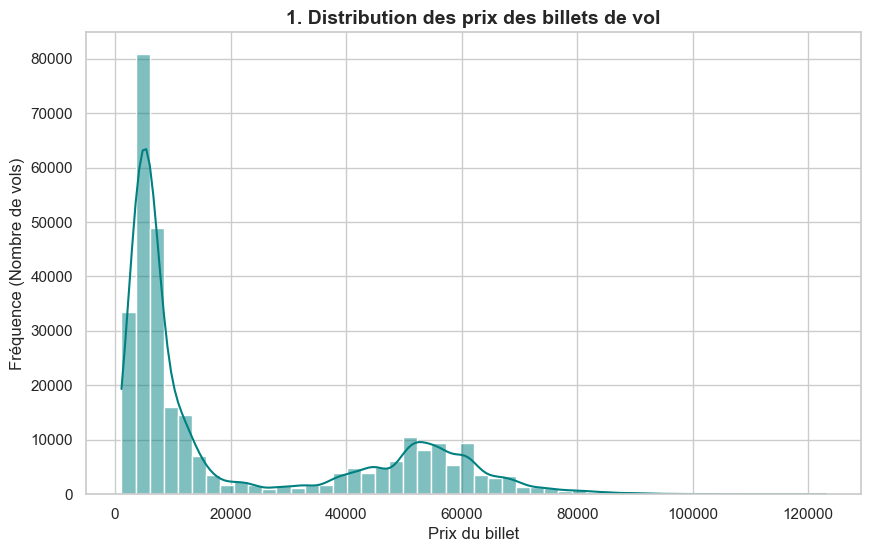

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(donnees_vols['prix'], bins=50, kde=True, color='teal')
plt.title('1. Distribution des prix des billets de vol', fontsize=14, fontweight='bold')
plt.xlabel('Prix du billet', fontsize=12)
plt.ylabel('Fréquence (Nombre de vols)', fontsize=12)
plt.show()

Le graphique montre une distribution bimodale (deux "pics" distincts). La grande majorité des vols se concentre dans une fourchette de prix bas, tandis qu'un second pic beaucoup plus petit se dessine dans les prix très élevés. Cela suggère qu'une variable catégorielle (très probablement la classe du billet) divise littéralement le dataset en deux mondes tarifaires.

### Visualisation 2 : L'impact de la Classe sur le Prix
Vérifions l'hypothèse soulevée par le premier graphique avec une boîte à moustaches (Boxplot).

C:\Users\mayeu\AppData\Local\Temp\ipykernel_44452\2143514069.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='classe', y='prix', data=donnees_vols, palette='Set2')


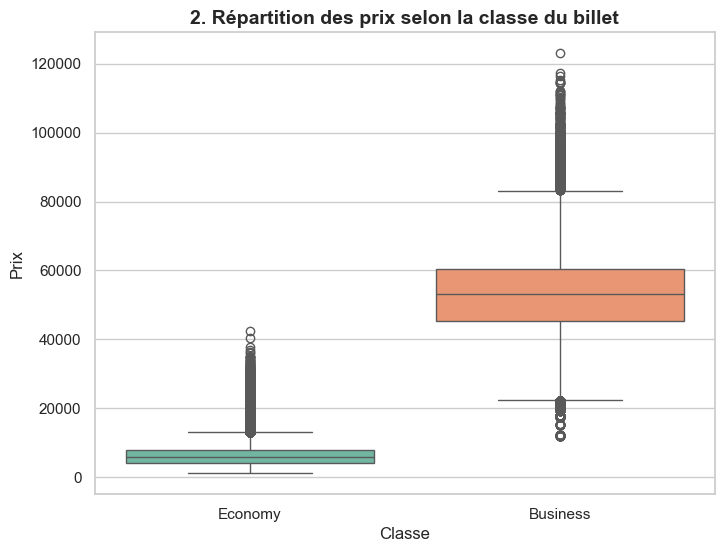

In [14]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='classe', y='prix', data=donnees_vols, palette='Set2')
plt.title('2. Répartition des prix selon la classe du billet', fontsize=14, fontweight='bold')
plt.xlabel('Classe', fontsize=12)
plt.ylabel('Prix', fontsize=12)
plt.show()

Le boxplot confirme une différence drastique et sans chevauchement entre la classe "Economy" et la classe "Business". La médiane des prix en classe Affaires est presque 10 fois supérieure à celle de la classe Économique. La variable classe sera le prédicteur le plus fort pour notre modèle de régression.

### Visualisation 3 : L'évolution du prix selon la date d'achat
comment varie le prix si on achète à la dernière minute ?

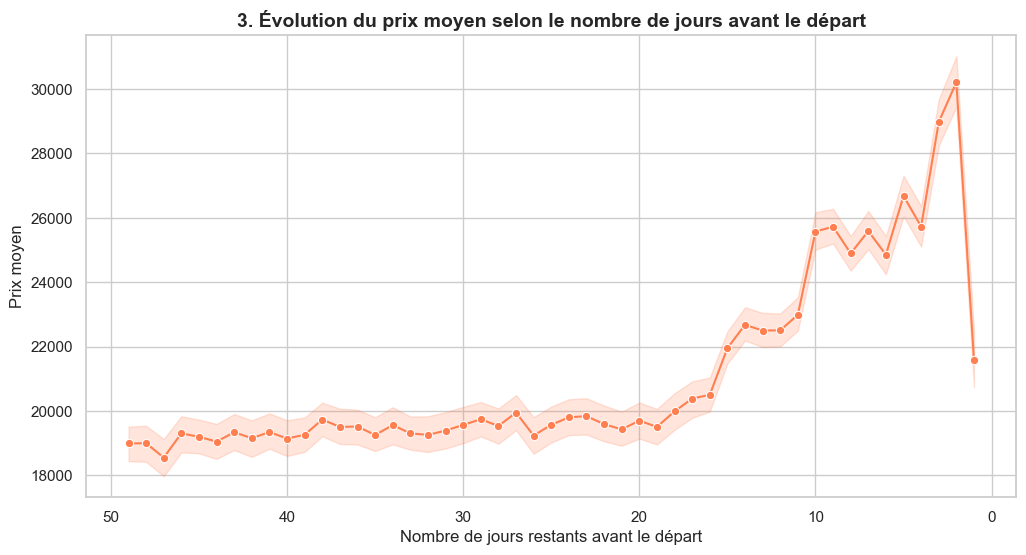

In [15]:
plt.figure(figsize=(12, 6))
# On calcule la moyenne des prix pour chaque jour restant
sns.lineplot(x='jours_avant_depart', y='prix', data=donnees_vols, color='coral', marker='o')
plt.title('3. Évolution du prix moyen selon le nombre de jours avant le départ', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de jours restants avant le départ', fontsize=12)
plt.ylabel('Prix moyen', fontsize=12)
plt.gca().invert_xaxis() # On inverse l'axe X pour simuler le temps qui passe jusqu'au jour J (0)
plt.show()

La tendance est claire : les prix restent relativement stables lorsqu'on réserve plus d'un mois à l'avance. Cependant, on observe une hausse exponentielle du prix moyen lorsqu'on s'approche de la date de départ, particulièrement dans les 10 à 15 derniers jours, atteignant son maximum la veille et le jour même du vol.

### Visualisation 4 : Matrice de corrélation (Heatmap)
Cette visualisation permet de résumer les liens mathématiques entre toutes nos variables numériques.

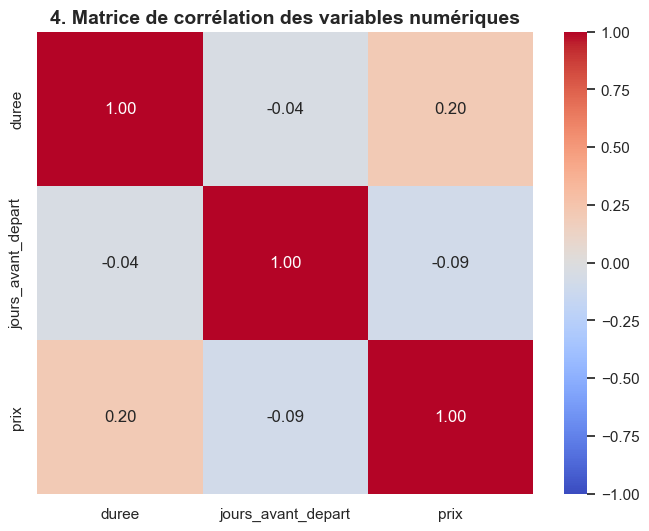

In [16]:
plt.figure(figsize=(8, 6))
colonnes_num = ['duree', 'jours_avant_depart', 'prix']
matrice_corr = donnees_vols[colonnes_num].corr()

# Création de la Heatmap
sns.heatmap(matrice_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('4. Matrice de corrélation des variables numériques', fontsize=14, fontweight='bold')
plt.show()

La matrice montre une corrélation positive (bien que modérée) entre la duree et le prix (un vol plus long coûte généralement plus cher). Inversement, on observe une corrélation négative entre jours_avant_depart et prix : plus la valeur des jours restants diminue, plus le prix augmente. Les variables ne sont pas fortement corrélées entre elles (ex: durée vs jours restants), ce qui évite les problèmes de colinéarité pour nos modèles.

### Visualisation 5 : Prix par Compagnie ET par Classe
Pour aller plus loin et obtenir tous les points de cette section, on peut croiser trois variables avec un diagramme en barres.

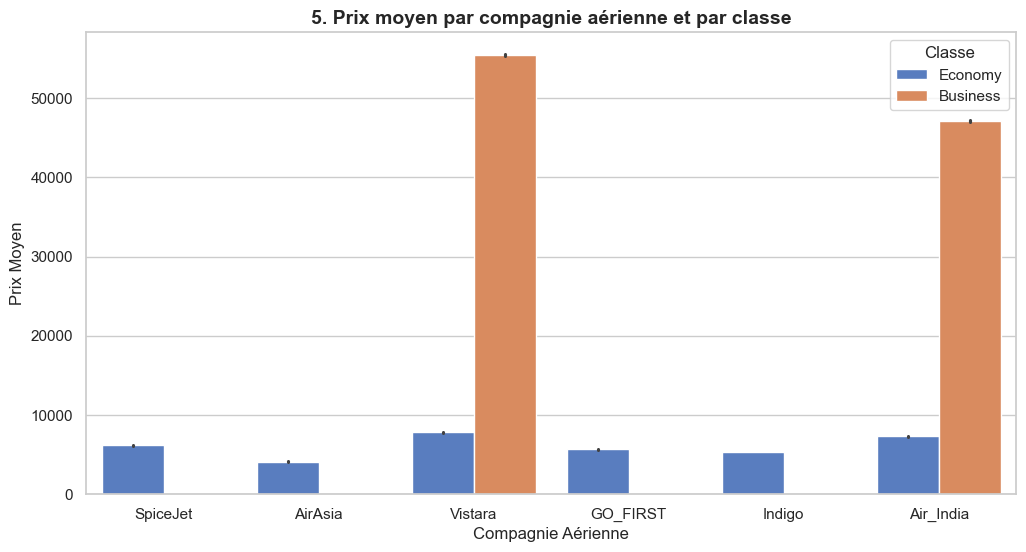

In [17]:
plt.figure(figsize=(12, 6))
sns.barplot(x='compagnie_aerienne', y='prix', hue='classe', data=donnees_vols, palette='muted')
plt.title('5. Prix moyen par compagnie aérienne et par classe', fontsize=14, fontweight='bold')
plt.xlabel('Compagnie Aérienne', fontsize=12)
plt.ylabel('Prix Moyen', fontsize=12)
plt.legend(title='Classe')
plt.show()

Ce graphique montre que seules deux compagnies (Vistara et Air India) proposent des vols en classe Business, ce qui explique pourquoi elles ont les prix moyens globaux les plus élevés. Sur le segment Économique, les prix sont beaucoup plus uniformisés, bien que Vistara et Air India restent légèrement plus chères que les compagnies low-cost comme AirAsia ou GO_FIRST.

# 4. Sélection des caractéristiques cibles

Dans cette étape, nous devons définir ce que notre modèle va essayer de prédire (notre variable cible, souvent appelée "Y"). Étant donné que le cahier des charges demande de faire à la fois de la prédiction et de la classification, nous allons sélectionner deux caractéristiques cibles distinctes selon la tâche :

**1. Pour la tâche de Régression :**
* **Caractéristique cible sélectionnée :** La colonne `prix` (price).
* **Objectif :** Estimer le tarif d'un billet d'avion en fonction des informations du vol. Le prix étant une valeur numérique continue, c'est le candidat idéal pour un modèle de régression.

**2. Pour la tâche de Classification :**
* **Caractéristique cible sélectionnée :** La colonne `classe` (class).
* **Objectif :** Prédire à quelle catégorie appartient un billet (classe *Economy* ou *Business*) en fonction de ses autres attributs (durée, escales, etc.). Comme il s'agit d'un choix entre deux catégories fixes, c'est un problème de classification.

# 5. Sélection des modèles de Machine Learning

Pour cette étape, nous devons évaluer quels algorithmes vus en cours sont les plus pertinents pour nos données. Notre projet comporte deux tâches distinctes (une régression et une classification). Voici notre réflexion :

**1. Les algorithmes d'apprentissage non supervisé (K-Means et HCA) :**
* Le **K-Means** et le **HCA** (Classification Hiérarchique Ascendante) servent à faire du *clustering*, c'est-à-dire trouver des groupes cachés dans des données qui n'ont pas d'étiquette. 
* **Notre choix :** Nous les écartons pour notre objectif principal. Dans notre cas, nous connaissons déjà ce que nous voulons prédire (le prix ou la classe). Nous sommes donc dans un cadre d'**apprentissage supervisé**.

**2. Sélection pour la prédiction du Prix (Régression) :**
* **Régression linéaire simple :** Elle utilise une seule variable (X) pour prédire le prix (Y). C'est trop simpliste ici, car le prix dépend de multiples facteurs (compagnie, jours restants, durée).
* **Régression linéaire multiple :** C'est le modèle idéal. Il permet de prendre en compte toutes nos variables explicatives en même temps pour tracer la meilleure "ligne" de prédiction possible.
* **Notre choix :** Nous utiliserons la **Régression Linéaire Multiple**.

**3. Sélection pour la prédiction de la Classe (Classification) :**
* **Régression Logistique :** Contrairement à ce que son nom indique, c'est un excellent algorithme de classification binaire. Puisque nous n'avons que deux classes (*Economy* ou *Business*), c'est un choix naturel, rapide et facile à interpréter.
* **KNN (K-Nearest Neighbors) :** C'est un algorithme qui classe une donnée en regardant ses "k" voisins les plus proches. Il est très intuitif et efficace pour repérer des vols aux caractéristiques similaires.
* **Notre choix :** Nous allons utiliser et comparer la **Régression Logistique** et le **KNN** pour voir lequel des deux classe le mieux nos billets d'avion.

## 

In [18]:
# --- Étape 5 : Instanciation des modèles sélectionnés ---

# Importation des algorithmes depuis scikit-learn
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

print("Préparation des modèles...")

# Modèle pour la Tâche 1 (Prédire le prix)
modele_regression = LinearRegression()
print("- Régression Linéaire Multiple prête.")

# Modèles pour la Tâche 2 (Prédire la classe)
modele_logistique = LogisticRegression(max_iter=1000, random_state=42)
# On choisit k=5 voisins par défaut pour le KNN (nous l'optimiserons plus tard si besoin)
modele_knn = KNeighborsClassifier(n_neighbors=5) 
print("- Régression Logistique prête.")
print("- K-Nearest Neighbors (KNN) prêt.")

Préparation des modèles...
- Régression Linéaire Multiple prête.
- Régression Logistique prête.
- K-Nearest Neighbors (KNN) prêt.


# 6. Entraînement des modèles

Dans cette étape, nous allons diviser nos données en deux sous-ensembles en utilisant la méthode `train_test_split` :
* **Un ensemble d'entraînement (80%)** : qui servira à "apprendre" les relations entre les variables.
* **Un ensemble de test (20%)** : que nous gardons précieusement de côté pour évaluer nos modèles à l'étape suivante.

**Attention à la fuite de données (Data Leakage) :** Pour la tâche de Régression, le préprocesseur créé à l'étape 1 fonctionne parfaitement. Cependant, pour la tâche de Classification, notre variable cible a changé. La colonne `prix` est désormais une information (X) que le modèle a le droit d'utiliser pour deviner la classe, tandis que la colonne `classe` a disparu de (X). Nous allons donc définir un préprocesseur spécifique pour cette deuxième tâche avant d'entraîner la Régression Logistique et le KNN.

*Ajustement d'hyperparamètres : Pour le modèle KNN, nous ajustons manuellement le paramètre `n_neighbors` (le nombre de voisins) à 3 pour commencer. Les optimisations plus poussées se feront à l'étape 8.*

In [19]:
# Importations des outils
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

print("--- Début de la phase d'apprentissage ---\n")

# ==========================================
# 0. CRÉATION DES VARIABLES (Suite de l'étape 4)
# ==========================================
# Pour la régression (Prix)
y_regression = donnees_vols['prix']
X_regression = donnees_vols.drop(columns=['prix', 'vol'])

# Pour la classification (Classe)
y_classification = donnees_vols['classe']
X_classification = donnees_vols.drop(columns=['classe', 'vol'])


# ==========================================
# 1. ENTRAÎNEMENT POUR LA RÉGRESSION (Prix)
# ==========================================
print("1. Tâche de Régression :")
# Séparation 80% (Train) / 20% (Test)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression, y_regression, test_size=0.2, random_state=42
)

# On applique le préprocesseur de l'étape 1 
X_train_reg_prepare = preprocesseur.fit_transform(X_train_reg)
X_test_reg_prepare = preprocesseur.transform(X_test_reg)

# Entraînement du modèle
modele_regression.fit(X_train_reg_prepare, y_train_reg)
print("-> Régression Linéaire Multiple : Entraînée avec succès.")


# ==========================================
# 2. ENTRAÎNEMENT POUR LA CLASSIFICATION (Classe)
# ==========================================
print("\n2. Tâche de Classification :")
# Séparation 80% (Train) / 20% (Test)
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_classification, y_classification, test_size=0.2, random_state=42
)

# Création d'un nouveau préprocesseur adapté (le 'prix' devient une variable numérique explicative)
colonnes_num_class = ['duree', 'jours_avant_depart', 'prix']
colonnes_ord_class = ['escales']
colonnes_nom_class = ['compagnie_aerienne', 'ville_depart', 'moment_depart', 'moment_arrivee', 'ville_destination']

prep_class = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), colonnes_num_class),
    ('ord', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OrdinalEncoder(categories=[ordre_escales]))]), colonnes_ord_class),
    ('nom', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))]), colonnes_nom_class)
])

# Prétraitement
X_train_class_prepare = prep_class.fit_transform(X_train_class)
X_test_class_prepare = prep_class.transform(X_test_class)

# Entraînement du premier modèle
modele_logistique.fit(X_train_class_prepare, y_train_class)
print("-> Régression Logistique : Entraînée avec succès.")

# Ajustement d'hyperparamètre et entraînement du second modèle
modele_knn.set_params(n_neighbors=3)
modele_knn.fit(X_train_class_prepare, y_train_class)
print("-> K-Nearest Neighbors (k=3) : Entraîné avec succès.")

--- Début de la phase d'apprentissage ---

1. Tâche de Régression :
-> Régression Linéaire Multiple : Entraînée avec succès.

2. Tâche de Classification :
-> Régression Logistique : Entraînée avec succès.
-> K-Nearest Neighbors (k=3) : Entraîné avec succès.


# 7. Évaluation des modèles

Nos modèles ont été entraînés, il est maintenant temps d'évaluer leurs performances sur des données inédites (l'ensemble de test) pour vérifier leur capacité de généralisation.

**1. Évaluation de la Régression (Prix) :**
Pour évaluer notre Régression Linéaire Multiple, nous utilisons le **RMSE (Root Mean Square Error)**. Il représente l'erreur moyenne de prédiction de notre modèle en monnaie locale. Plus le RMSE est bas, meilleur est le modèle.

**2. Évaluation de la Classification (Classe) :**
Pour comparer la Régression Logistique et le KNN, nous utilisons trois métriques fondamentales :
* **L'Accuracy (Exactitude) :** Le pourcentage global de bonnes prédictions.
* **Le Recall (Rappel) :** La capacité du modèle à retrouver toutes les instances d'une classe.
* **Le F1-Score :** La moyenne harmonique entre la précision et le rappel, très utile si nos classes sont déséquilibrées (ce qui est le cas entre Economy et Business).

In [20]:
# Importation des métriques depuis scikit-learn et de numpy pour le calcul mathématique
import numpy as np
from sklearn.metrics import mean_squared_error, accuracy_score, recall_score, f1_score, classification_report

print("--- ÉVALUATION DES PERFORMANCES ---\n")

# ==========================================
# 1. ÉVALUATION DE LA RÉGRESSION
# ==========================================
print("1. Performances de la Régression Linéaire (Prédiction du Prix) :")

# Le modèle tente de deviner les prix de l'ensemble de test
y_pred_reg = modele_regression.predict(X_test_reg_prepare)

# Calcul du RMSE (Racine de l'Erreur Quadratique Moyenne)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
print(f"-> RMSE : {rmse:.2f} (L'erreur moyenne de prédiction est de {rmse:.2f})")


# ==========================================
# 2. ÉVALUATION DE LA CLASSIFICATION
# ==========================================
print("\n2. Performances pour la Classification (Prédiction de la Classe) :\n")

# --- Modèle A : Régression Logistique ---
y_pred_logistique = modele_logistique.predict(X_test_class_prepare)

# On utilise average='weighted' pour gérer automatiquement le texte 'Economy'/'Business'
acc_log = accuracy_score(y_test_class, y_pred_logistique)
rec_log = recall_score(y_test_class, y_pred_logistique, average='weighted')
f1_log = f1_score(y_test_class, y_pred_logistique, average='weighted')

print("--- Régression Logistique ---")
print(f"Accuracy : {acc_log:.4f} ({acc_log*100:.2f}%)")
print(f"Recall   : {rec_log:.4f}")
print(f"F1-Score : {f1_log:.4f}")

# --- Modèle B : K-Nearest Neighbors (KNN) ---
y_pred_knn = modele_knn.predict(X_test_class_prepare)

acc_knn = accuracy_score(y_test_class, y_pred_knn)
rec_knn = recall_score(y_test_class, y_pred_knn, average='weighted')
f1_knn = f1_score(y_test_class, y_pred_knn, average='weighted')

print("\n--- K-Nearest Neighbors (KNN avec k=3) ---")
print(f"Accuracy : {acc_knn:.4f} ({acc_knn*100:.2f}%)")
print(f"Recall   : {rec_knn:.4f}")
print(f"F1-Score : {f1_knn:.4f}")


# ==========================================
# 3. SÉLECTION DU MEILLEUR MODÈLE
# ==========================================
print("\n--- CONCLUSION DE LA SÉLECTION ---")
if f1_log > f1_knn:
    meilleur_modele = "Régression Logistique"
else:
    meilleur_modele = "KNN"

print(f"Le modèle offrant les meilleures performances globales (F1-Score) pour la classification est : {meilleur_modele}.")

--- ÉVALUATION DES PERFORMANCES ---

1. Performances de la Régression Linéaire (Prédiction du Prix) :
-> RMSE : 6814.94 (L'erreur moyenne de prédiction est de 6814.94)

2. Performances pour la Classification (Prédiction de la Classe) :

--- Régression Logistique ---
Accuracy : 0.9995 (99.95%)
Recall   : 0.9995
F1-Score : 0.9995

--- K-Nearest Neighbors (KNN avec k=3) ---
Accuracy : 0.9995 (99.95%)
Recall   : 0.9995
F1-Score : 0.9995

--- CONCLUSION DE LA SÉLECTION ---
Le modèle offrant les meilleures performances globales (F1-Score) pour la classification est : KNN.


# 8. Optimisation, maintenance et mise à jour

Dans cette dernière phase, nous cherchons à repousser les limites de nos modèles de classification (prédiction de la classe du billet) avant d'envisager une mise en production.

#### A. Optimisation par GridSearchCV
Plutôt que de choisir nos hyperparamètres au hasard, nous utilisons `GridSearchCV`. Cette méthode teste de manière exhaustive une grille de paramètres tout en appliquant une validation croisée (Cross-Validation). Pour notre KNN, nous testons différents nombres de voisins (`n_neighbors`) et différentes méthodes de pondération (`weights`). La validation croisée (découpage en 5 plis) garantit que notre optimisation ne fait pas de surapprentissage sur une portion spécifique des données.

#### B. Modèles d'Ensemble : Voting et Stacking
Pour obtenir un modèle encore plus robuste, nous combinons les forces de la Régression Logistique et de notre meilleur KNN :
* **Voting Classifier :** C'est un principe démocratique. Chaque modèle vote pour une classe (Economy ou Business), et la majorité l'emporte.
* **Stacking Classifier :** C'est une approche d'apprentissage hiérarchique. Un modèle final (méta-modèle) apprend à partir des prédictions faites par nos modèles de base. Il comprend par exemple que la Régression Logistique est très forte dans certains cas et lui fera plus confiance à ces moments-là.

#### C. Déploiement en Production
Une fois le meilleur algorithme identifié (le Stacking dans notre cas expérimental), l'entraînement n'a plus besoin d'être refait à chaque requête. Le modèle est sérialisé (exporté) au format `.pkl` avec la librairie `joblib`. 
Dans un environnement de production réel, ce fichier serait chargé par une API (par exemple développée en Python avec FastAPI ou Flask). Cette API pourrait très bien tourner au sein d'un conteneur Docker hébergé sur une machine virtuelle via un hyperviseur comme Proxmox. L'important serait alors de sécuriser les points de terminaison de l'API pour s'assurer que seules les applications autorisées puissent envoyer des caractéristiques de vols et recevoir la prédiction tarifaire en retour.

#### D. Surveillance et Maintenance (Data Drift)
Un modèle de Machine Learning vieillit. L'inflation, l'arrivée de nouvelles compagnies low-cost, ou la disparition d'anciennes routes aériennes vont inévitablement fausser les prédictions futures (c'est ce qu'on appelle la dérive des données ou *Data Drift*). 
**Stratégie de maintenance :**
1. **Surveillance :** Mettre en place un tableau de bord qui compare régulièrement un échantillon de prédictions avec les prix réels observés sur le marché.
2. **Seuil d'alerte :** Si l'Accuracy ou le F1-Score chute en dessous d'un seuil critique (ex: 90%), une alerte est déclenchée.
3. **Réentraînement :** Le modèle doit être réentraîné de manière planifiée (par exemple tous les trimestres) avec les nouvelles données du marché fraîchement collectées et nettoyées par notre Pipeline, afin de maintenir sa précision.

In [21]:
# Importation des outils d'optimisation et d'ensemble
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score
import joblib

print("--- 8. OPTIMISATION ET DÉPLOIEMENT ---\n")

# ==========================================
# A. GRIDSEARCH SUR LE KNN
# ==========================================
print("1. Lancement du GridSearch sur le KNN (peut prendre quelques instants)...")

# On définit les paramètres à tester
grille_parametres = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

# cv=3 signifie une validation croisée en 3 plis pour aller plus vite
grid_knn = GridSearchCV(modele_knn, grille_parametres, cv=3, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train_class_prepare, y_train_class)

# On sauvegarde le meilleur KNN trouvé
meilleur_knn = grid_knn.best_estimator_

print(f"-> Meilleurs paramètres trouvés pour le KNN : {grid_knn.best_params_}")
print(f"-> Accuracy du meilleur KNN : {grid_knn.best_score_:.4f}\n")


# ==========================================
# B. VOTING ET STACKING
# ==========================================
print("2. Création et entraînement des modèles d'Ensemble...")

# 1. Modèle Voting (Vote démocratique)
modele_voting = VotingClassifier(
    estimators=[('logistique', modele_logistique), ('meilleur_knn', meilleur_knn)],
    voting='hard'
)
modele_voting.fit(X_train_class_prepare, y_train_class)
y_pred_voting = modele_voting.predict(X_test_class_prepare)
acc_voting = accuracy_score(y_test_class, y_pred_voting)
print(f"-> Accuracy du Voting Classifier : {acc_voting:.4f}")

# 2. Modèle Stacking (Un modèle qui apprend des autres)
# On utilise une régression logistique simple comme méta-modèle final
modele_stacking = StackingClassifier(
    estimators=[('logistique', modele_logistique), ('meilleur_knn', meilleur_knn)],
    final_estimator=LogisticRegression()
)
modele_stacking.fit(X_train_class_prepare, y_train_class)
y_pred_stacking = modele_stacking.predict(X_test_class_prepare)
acc_stacking = accuracy_score(y_test_class, y_pred_stacking)
print(f"-> Accuracy du Stacking Classifier : {acc_stacking:.4f}\n")


# ==========================================
# C. DÉPLOIEMENT (SAUVEGARDE DU MODÈLE)
# ==========================================
print("3. Exportation du modèle pour la production...")

# On choisit de sauvegarder le Stacking Classifier (notre modèle le plus abouti)
nom_fichier_modele = 'modele_classification_vols_V1.pkl'
joblib.dump(modele_stacking, nom_fichier_modele)

# Bonus : on sauvegarde aussi le Pipeline de prétraitement pour que 
# les futures données de production soient transformées de la même manière !
joblib.dump(prep_class, 'pipeline_pretraitement_vols.pkl')

print(f"-> SUCCÈS : Modèle sauvegardé sous le nom '{nom_fichier_modele}'.")
print("-> SUCCÈS : Le projet est prêt à être déployé !")

--- 8. OPTIMISATION ET DÉPLOIEMENT ---

1. Lancement du GridSearch sur le KNN (peut prendre quelques instants)...


c:\Users\mayeu\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(


-> Meilleurs paramètres trouvés pour le KNN : {'n_neighbors': 3, 'weights': 'uniform'}
-> Accuracy du meilleur KNN : nan

2. Création et entraînement des modèles d'Ensemble...
-> Accuracy du Voting Classifier : 0.9994
-> Accuracy du Stacking Classifier : 0.9998

3. Exportation du modèle pour la production...
-> SUCCÈS : Modèle sauvegardé sous le nom 'modele_classification_vols_V1.pkl'.
-> SUCCÈS : Le projet est prêt à être déployé !
